# Intra-Beam Scattering and Stochastic Cooling
The following research made for NICA collider proton beam mode.
In order to investigate the possibility of usage a stochastic cooling for proton beam.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymadx as madx

IBS calculated as follows at [CERN-ATS-2012-066](https://cds.cern.ch/record/1445924) for each element

$$
\begin{aligned}
\frac{1}{\tau_x} & =\frac{\pi^2 r_0^2 v_c m^3 N(\log )}{\gamma \Gamma}\left[\frac{\gamma^2 H_x}{\epsilon_x}\right] \int_0^{\infty} \frac{d \lambda \lambda^{1 / 2}\left[a_x \lambda+b_x\right]}{\left(\lambda^3+a \lambda^2+b \lambda+c\right)^{3 / 2}}, \\
\frac{1}{\tau_l} & =\frac{\pi^2 r_0^2 v_c m^3 N(\log )}{\gamma \Gamma}\left[\frac{\gamma^2}{\sigma_\delta^2}\right] \int_0^{\infty} \frac{d \lambda \lambda^{1 / 2}\left[a_l \lambda+b_l\right]}{\left(\lambda^3+a \lambda^2+b \lambda+c\right)^{3 / 2}}, \\
\frac{1}{\tau_y} & =\frac{\pi^2 r_0^2 v_c m^3 N(\log )}{\gamma \Gamma}\left[\frac{\beta_y}{\epsilon_y}\right] \int_0^{\infty} \frac{d \lambda \lambda^{1 / 2}\left[a_y \lambda+b_y\right]}{\left(\lambda^3+a \lambda^2+b \lambda+c\right)^{3 / 2}} .
\end{aligned}
$$

And averaged over the lattice as

$$
\frac{1}{\tau} = \frac{1}{C_{ring}}\sum_{i}\frac{1}{\tau_{i}}\times\Delta s
$$

Read the table with (Weighted) average lifetimes [s] in three planes. 
Calculation made with MADX IBS Module, based on analitical integration over the lattice.

In [2]:
IBS_time = pd.read_table('IBS_data_proton.dat', sep=r'\s+')
structure = pd.read_table('IBS_structure.dat', sep=r'\s+')
beam = pd.read_table('IBS_beam.dat', sep=r'\s+')
E_tr = 5.7 # GeV
E_exp = 12.6 #GeV

Define the minimal positive time and the plane as dominant effect of IBS.

In [3]:
# Columns with (weighted) average lifetimes (sec):
time_cols = ['t_l', 't_h', 't_v']

for col in time_cols:
    IBS_time[col] = pd.to_numeric(IBS_time[col], errors='coerce') 

effect_names = ['Longitudinal', 'Horizontal', 'Vertical']

# Function to get minimal value of positive IBS Time in three planes
def get_min_details(row):
    """
    Identifies the minimum positive time and the dominant IBS effect.
    Returns a tuple: (min_positive_time, dominant_effect_name)
    """
    # --- The Fix: Explicitly cast the values to float64 here ---
    vals = np.abs(row[time_cols].values).astype(np.float64)
    # -----------------------------------------------------------
    
    positive_vals = np.where(vals > 0, vals, np.nan)
    
    # These NumPy functions should now work without TypeError
    if np.all(np.isnan(positive_vals)):
        return np.nan, "No Growth"
    
    min_index = np.nanargmin(positive_vals)
    min_value = positive_vals[min_index]
    dominant_name = effect_names[min_index]
    
    return min_value, dominant_name

IBS_time[['t_min_positive', 'Dominant_Effect']] = IBS_time.apply(get_min_details, axis=1, result_type='expand')
#Also make an avarage
IBS_time['t_all'] = IBS_time.apply(lambda row: 1/((1/row.t_l) + (1/row.t_h) + (1/row.t_v)), axis=1)
print(IBS_time)

   structure  kinetic_energy         t_l           t_h           t_v  \
0    Regular             1.0   -142.3648     18.547130      17.72179   
1    Regular             2.0   -759.3774    204.171700     206.86910   
2    Regular             3.0 -11806.1200    993.603900    1381.96700   
3    Regular             4.0   5221.1350   2702.243000    8426.68700   
4    Regular             4.5   4425.9920   3777.660000   24544.69000   
5    Regular             5.0   4276.7340   4905.268000  156714.00000   
6    Regular             5.7   4463.2310   6516.377000  -88634.18000   
7    Regular             6.0   4621.7250   7217.599000  -71867.29000   
8    Regular             7.0   5369.7290   9645.376000  -67446.42000   
9    Regular             8.0   6380.9730  12302.290000  -83089.41000   
10   Regular             9.0   7620.9390  15283.110000 -109683.10000   
11   Regular            10.0   9083.1530  18655.670000 -147523.80000   
12   Regular            11.0  10771.2100  22471.240000 -198615.3

**Plot defined value for various lattices.**

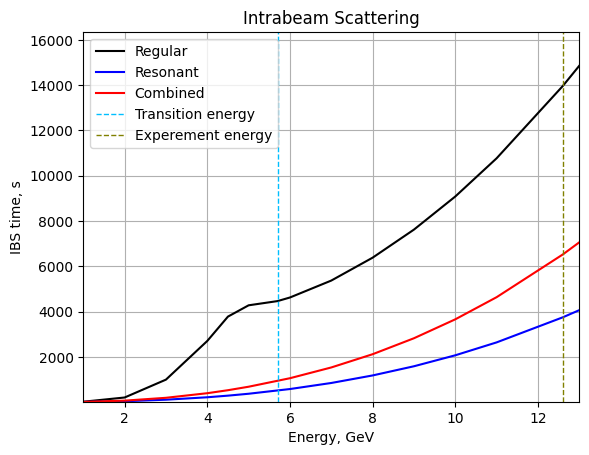

In [4]:
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_min_positive'], 'k')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_min_positive'], 'b')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_min_positive'], 'r')
plt.title("Intrabeam Scattering")
plt.xlabel('Energy, GeV')
plt.ylabel('IBS time, s')
plt.grid()
plt.xlim(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].min(), IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].max())
plt.ylim(IBS_time[IBS_time['structure'] == 'Regular']['t_min_positive'].min(), IBS_time[IBS_time['structure'] == 'Regular']['t_min_positive'].max()*1.1)
#Add transition energy line and experemental target
plt.axvline(x=E_tr,
           color = 'deepskyblue',
           linestyle='--',     
           linewidth=1,        
           label='Transition energy')
plt.axvline(x=E_exp,
           color = 'olive',
           linestyle='--',     
           linewidth=1,        
           label='Experement energy')
plt.legend(['Regular', 'Resonant', 'Combined', 'Transition energy', 'Experement energy'])
plt.show()

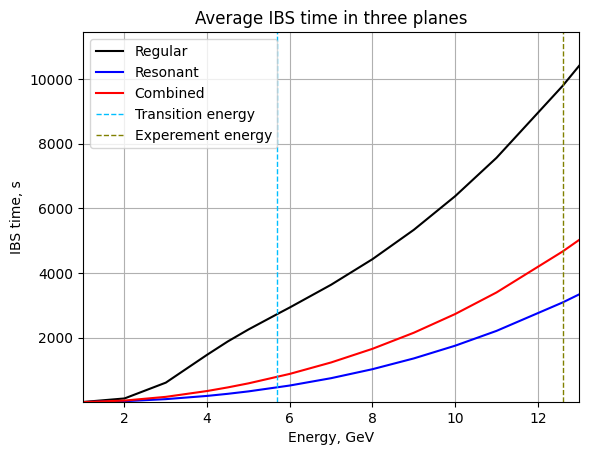

In [5]:
#Average value
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_all'], 'k')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_all'], 'b')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_all'], 'r')
plt.title("Average IBS time in three planes")
plt.xlabel('Energy, GeV')
plt.ylabel('IBS time, s')
plt.grid()
plt.xlim(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].min(), IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].max())
plt.ylim(IBS_time[IBS_time['structure'] == 'Regular']['t_min_positive'].min(), IBS_time[IBS_time['structure'] == 'Regular']['t_all'].max()*1.1)
#Add transition energy line and experemental target
plt.axvline(x=E_tr,
           color = 'deepskyblue',
           linestyle='--',     
           linewidth=1,        
           label='Transition energy')
plt.axvline(x=E_exp,
           color = 'olive',
           linestyle='--',     
           linewidth=1,        
           label='Experement energy')
plt.legend(['Regular', 'Resonant', 'Combined', 'Transition energy', 'Experement energy'])
plt.show()

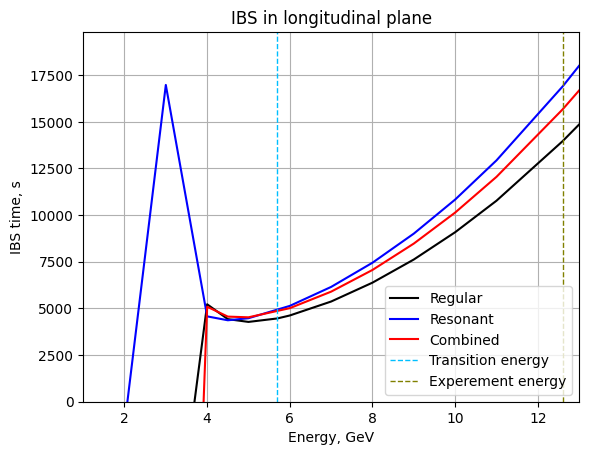

In [6]:
#Longitudinal IBS
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_l'], 'k')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_l'], 'b')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_l'], 'r')
plt.title("IBS in longitudinal plane")
plt.xlabel('Energy, GeV')
plt.ylabel('IBS time, s')
plt.grid()
plt.xlim(1, IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].max())
plt.ylim(0, IBS_time[IBS_time['structure'] == 'Resonant']['t_l'].max()*1.1)
#Add transition energy line and experemental target
plt.axvline(x=E_tr,
           color = 'deepskyblue',
           linestyle='--',     
           linewidth=1,        
           label='Transition energy')
plt.axvline(x=E_exp,
           color = 'olive',
           linestyle='--',     
           linewidth=1,        
           label='Experement energy')
plt.legend(['Regular', 'Resonant', 'Combined', 'Transition energy', 'Experement energy'])
plt.show()

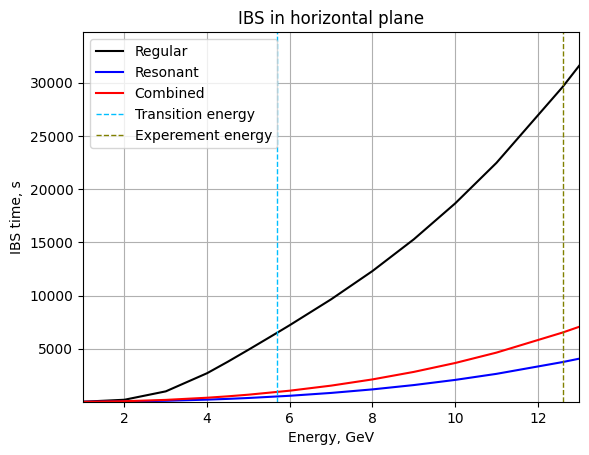

In [7]:
#Horizontal IBS
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_h'], 'k')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_h'], 'b')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_h'], 'r')
plt.title("IBS in horizontal plane")
plt.xlabel('Energy, GeV')
plt.ylabel('IBS time, s')
plt.grid()
plt.xlim(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].min(), IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].max())
plt.ylim(IBS_time[IBS_time['structure'] == 'Regular']['t_h'].min(), IBS_time[IBS_time['structure'] == 'Regular']['t_h'].max()*1.1)
#Add transition energy line and experemental target
plt.axvline(x=E_tr,
           color = 'deepskyblue',
           linestyle='--',     
           linewidth=1,        
           label='Transition energy')
plt.axvline(x=E_exp,
           color = 'olive',
           linestyle='--',     
           linewidth=1,        
           label='Experement energy')
plt.legend(['Regular', 'Resonant', 'Combined', 'Transition energy', 'Experement energy'])
plt.show()

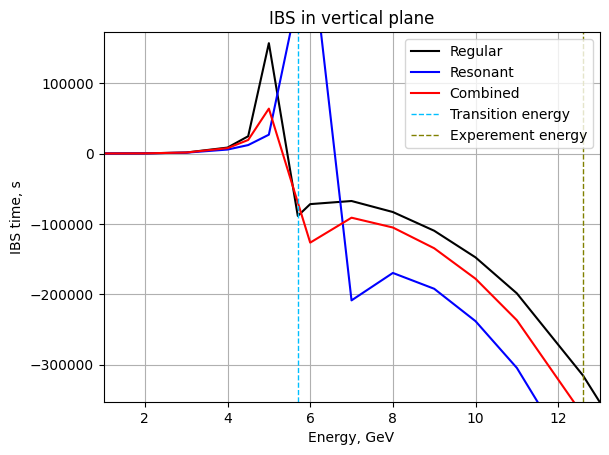

In [8]:
#Vertical IBS
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_v'], 'k')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_v'], 'b')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_v'], 'r')
plt.title("IBS in vertical plane")
plt.xlabel('Energy, GeV')
plt.ylabel('IBS time, s')
plt.grid()
plt.xlim(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].min(), IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'].max())
plt.ylim(IBS_time[IBS_time['structure'] == 'Regular']['t_v'].min(), IBS_time[IBS_time['structure'] == 'Regular']['t_v'].max()*1.1)
#Add transition energy line and experemental target
plt.axvline(x=E_tr,
           color = 'deepskyblue',
           linestyle='--',     
           linewidth=1,        
           label='Transition energy')
plt.axvline(x=E_exp,
           color = 'olive',
           linestyle='--',     
           linewidth=1,        
           label='Experement energy')
plt.legend(['Regular', 'Resonant', 'Combined', 'Transition energy', 'Experement energy'])
plt.show()

# Stochastic Cooling
Here represent the Analitical Calculation.
$$
\frac{1}{\tau_{\text{tr, l}}}=\frac{W}{N}[\underbrace{2 g \cos \theta\left(1-1 / M_{\text{pk}}^2\right)}_{\begin{array}{c}
\text { coherent } \\
\text { effect(cooling) }
\end{array}}-\underbrace{g^2\left(M_{\text{kp}}+U\right)}_{\begin{array}{c}
\text { incoherent } \\
\text { effect(heating) }
\end{array}}]
$$

In [9]:
#parameters
c = 3*1e8 # m/s, speed of light
m_p = 0.938 # GeV
f_max = 4*1e9 # Hz
f_min = 2*1e9 # Hz
W = f_max - f_min # Hz, bandwidth of the system
N_bunch = 1.2*1e12 # number of particles per one bunch
C_orb = 503.04 # m Accelerator length
F_bunch = 4 # bunch distribution parameter: 2pi - gauss, 4 - 
sigma_bunch = 0.6 # m, longitudinal sigma length
dp_p = 1.5*1e-3

In [10]:
N = N_bunch * (C_orb / (F_bunch * sigma_bunch)) # number of particles on orbit
N/1e14

2.5152

Optimal value of cooling

In [11]:
nu = W / N
nu_Lebedev = (4*W*sigma_bunch) / (N_bunch*C_orb)
tau_Lebedev = 1 / nu_Lebedev
tau_limit = 1 / nu # limitation
print( (1/nu)/1e5, (1/nu_Lebedev)/1e5)

1.2576000000000003 1.2576


Momentum compaction factor calculation

In [12]:
# The following data taken from OptiM (MADX) integrals
# alpha means Momentum compaction factor
alpha_1 = 0.0279239  # MCF in regular arc between pickup-kicker
alpha_2 = 0.0154573  # MCF in regular arc between kicker-pickup
L_1 = 179.696        # length between pickup-kicker
alpha_3 = 0.00587438 # MCF in Resosnant arc between pickup-kicker
alpha_4 = 0.00320331 # MCF in Resosnant arc between kicker-pickup
L_2 = 323.344        # length between kicker-pickup

Mixing factors
$$
\begin{aligned}
& M_{\text{pk}}=\frac{1}{2\left(f_{\max }+f_{\min }\right) \eta_{\text{pk}} T_{\text{pk}} \frac{\Delta p}{p}}, \\
& M_{\text{kp}}=\frac{1}{2\left(f_{\max }-f_{\min }\right) \eta_{\text{kp}} T_{\text{kp}} \frac{\Delta p}{p}},
\end{aligned}
$$

In [13]:
import numpy as np
def beta (gamma):
    return np.sqrt(1 - 1 / gamma**2)
def gamma (kinetic_energy, # GeV
           mass #mass
          ):
    return (kinetic_energy / mass) + 1
def eta (alpha, gamma):
    return alpha - (1 / (gamma**2))
# Time of fligth
def T (gamma, L):
    return L / (beta(gamma)*c)
#Mixing factor pickup-kicker
def M_pk (f_max, 
          f_min,
          gamma,
          alpha_pk, # alpha pickup - kicker
          L_pk, # Length
          dp_p):
    return 1 / (2 * (f_max+f_min)*eta(alpha_pk, gamma)*T(gamma, L_pk)*dp_p)
#Mixing factor pickup-kicker
def M_kp (f_max, 
          f_min,
          gamma,
          alpha_kp, # alpha kicker - pickup
          L_kp, # Length
          dp_p):
    return 1 / (2 * (f_max-f_min)*eta(alpha_kp, gamma)*T(gamma, L_kp)*dp_p)

Rate at optimal $g$ value
$$
\frac{1}{\tau_{\text{tr}}}=\frac{W}{N} \frac{\left(1-1 / M_{\text{pk}}^2\right)^2}{M_{\text{kp}}}
$$

In [14]:
def rate (f_max, 
          f_min,
          gamma,
          alpha_pk, # alpha pickup - kicker
          L_pk, # Length
          alpha_kp, # alpha kicker - pickup
          L_kp, # Length
          dp_p):
    return (W / N) * (1-1/(M_pk(f_max, f_min, gamma, alpha_pk, L_pk, dp_p))**2)**2/(M_kp(f_max, f_min, gamma, alpha_kp, L_kp, dp_p))
def tau (f_max, 
         f_min,
         gamma,
         alpha_pk, # alpha pickup - kicker
         L_pk, # Length
         alpha_kp, # alpha kicker - pickup
         L_kp, # Length
         dp_p):
    return 1 / rate(f_max, f_min, gamma, alpha_pk, L_pk, alpha_kp, L_kp, dp_p)

In [15]:
energy = np.linspace(0.0001, 15, 300)
tau_limitation = np.full(shape=energy.shape, fill_value = tau_limit)
tau_limitation_Lebedev = np.full(shape=energy.shape, fill_value = tau_Lebedev)

**Plot Transverse Stochastic Cooling for various lattices**

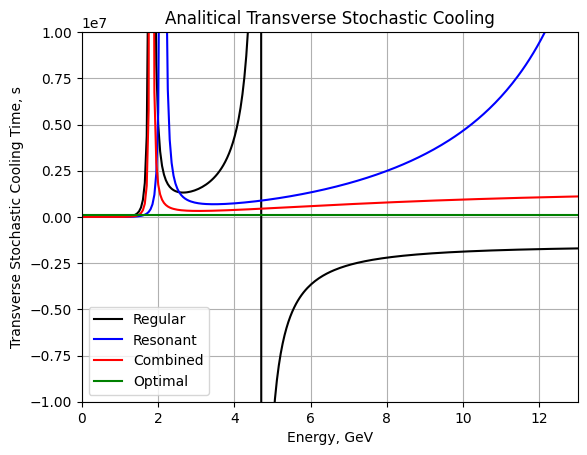

In [16]:
#plt.plot(energy, np.abs(tau(f_max, f_min, gamma(energy, m_p), alpha_1, L_1, alpha_2, L_2, dp_p)), 'k')
plt.plot(energy, -tau(f_max, f_min, gamma(energy, m_p), alpha_1, L_1, alpha_1, L_1, dp_p), 'k')
plt.plot(energy, -tau(f_max, f_min, gamma(energy, m_p), alpha_3, L_1, alpha_4, L_2, dp_p), 'b')
plt.plot(energy, -tau(f_max, f_min, gamma(energy, m_p), alpha_1, L_1, -alpha_2, L_2, dp_p), 'r')
plt.plot(energy, tau_limitation, 'g')
plt.ylim(-1e7, 1e7)
plt.xlim(0, 13)
plt.grid()
plt.xlabel('Energy, GeV')
plt.ylabel('Transverse Stochastic Cooling Time, s')
plt.legend(['Regular', 'Resonant', 'Combined', 'Optimal'])
plt.title("Analitical Transverse Stochastic Cooling")
plt.show()

**Compare Stochastic Cooling with Intra-Beam Scattering**

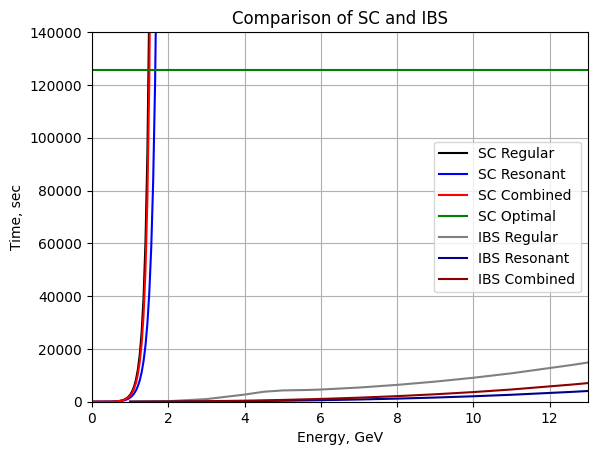

In [17]:
plt.plot(energy, np.abs(tau(f_max, f_min, gamma(energy, m_p), alpha_1, L_1, alpha_2, L_2, dp_p)),'k')
plt.plot(energy, np.abs(tau(f_max, f_min, gamma(energy, m_p), alpha_3, L_1, alpha_4, L_2, dp_p)), 'b')
plt.plot(energy, np.abs(tau(f_max, f_min, gamma(energy, m_p), alpha_1, L_1, -alpha_2, L_2, dp_p)), 'r')
plt.plot(energy, tau_limitation, 'g')
plt.plot(IBS_time[IBS_time['structure'] == 'Regular']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Regular']['t_min_positive'], 'gray')
plt.plot(IBS_time[IBS_time['structure'] == 'Resonant']['kinetic_energy'], IBS_time[IBS_time['structure'] == 'Resonant']['t_min_positive'], 'darkblue')
plt.plot(IBS_time[IBS_time['structure'] == 'Combined']['kinetic_energy'],IBS_time[IBS_time['structure'] == 'Combined']['t_min_positive'], 'darkred')
plt.ylim(0, 1.4e5)
plt.xlim(0, 13)
plt.grid()
plt.xlabel('Energy, GeV')
plt.ylabel('Time, sec')
plt.legend(['SC Regular', 'SC Resonant', 'SC Combined', 'SC Optimal', 'IBS Regular', 'IBS Resonant', 'IBS Combined'])
plt.title("Comparison of SC and IBS")
plt.show()